<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/Main_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#%pip install torch matplotlib

In [1]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.9 MB/s eta 0:00:00


In [ ]:
#!pip install table_evaluator

#Imports

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive
import os
from ctgan import CTGAN
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import time
import joblib

#Mount Drive

In [4]:
#!rm -rf /content/drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
base_path = "/content/drive/MyDrive/datasets/vehicle_sales"

!ls

drive  sample_data


#CTGAN on Vehicle Sales

#Import The Data

In [6]:
def handle_missing_continuous(df, continuous_cols, strategy="median"):

    for col in continuous_cols:

        df[col] = pd.to_numeric(df[col], errors="coerce")

        #df[col] = (df[col].replace(["NaN", "NULL", ""], np.nan))
        #Skip column if there are no nulls
        if not df[col].isna().any():
          continue

        #Create missing
        print(f"{col} - {str(df[col].isna().astype(int).unique())}")
        df[f"{col}_missing"] = df[col].isna().astype(int)

        #Impute values
        if strategy == "median":
            fill_value = df[col].median()
        elif strategy == "mean":
            fill_value = df[col].mean()
        elif strategy == "zero":
            fill_value = 0
        else:
            raise ValueError("Unsupported strategy")

        df[col] = df[col].fillna(fill_value)

    return df

In [8]:
vs_df = pd.read_csv(base_path+"/train.csv")
print(vs_df.head())
print(vs_df.shape)

   year      make       model         trim       body transmission  \
0  2010  Chrysler  PT Cruiser      Classic      Wagon    automatic   
1  2008    Nissan      Altima       3.5 SE      Sedan    automatic   
2  2012      Jeep     Liberty        Sport        SUV    automatic   
3  2009      Jeep    Wrangler  Unlimited X        suv    automatic   
4  2013    Nissan        Juke            S  Hatchback    automatic   

                 vin state  condition  odometer   color interior  \
0  3a4gy5f97at172213    tn       26.0   67969.0    gray     gray   
1  1n4bl21ex8c168024    pa        2.0  126302.0    gray    black   
2  1c4pjlak6cw100859    tx        2.0   68499.0   green    black   
3  1j4ga391x9l706276    fl       36.0   63592.0  yellow     gray   
4  jn8af5mrxdt213006    tx       39.0   33185.0   white    black   

                                seller      mmr  sellingprice  \
0                     tdaf remarketing   5225.0        5500.0   
1                 valley national bank  

In [ ]:
print(vs_df["mmr"].isna().any())

print(vs_df["mmr"].isna().all())

print(vs_df["sellingprice"].isna().any())

print(vs_df["sellingprice"].isna().all())

#print(vs_df["mmr"].unique()[:1000])

#print(vs_df["mmr_missing"].nunique())

True
False
True
False


#Preprocessing

In [7]:
def preprocess(df):
  df = handle_missing_continuous(
      df.copy(),
      continuous_cols=["year", "condition", "odometer", "mmr", "sellingprice"]
  )

  # Step 1: clean string
  df["saledate"] = df["saledate"].astype(str)
  df["saledate"] = df["saledate"].str.replace(r"GMT.*", "", regex=True)

  # Step 2: parse safely
  df["saledate"] = pd.to_datetime(df["saledate"], errors="coerce")

  # Step 3: inspect failures
  print(df["saledate"].isna().sum())

  # Step 4: handle missing
  df = df[df["saledate"].notna()]

  #df["saledate"] = pd.to_datetime(df["saledate"], errors="coerce")

  df["saledate"] = df["saledate"].dt.tz_localize(None)
  df["sale_year"] = df["saledate"].dt.year
  df["sale_month"] = df["saledate"].dt.month
  df["sale_day"] = df["saledate"].dt.day
  df["sale_hour"] = df["saledate"].dt.hour
  df = df.drop(columns=["vin", "trim", "seller", "saledate", "interior", "make", "transmission"])

  # df["transmission"] = df.groupby("model")["transmission"].transform(
  #     lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "UNKNOWN")
  # )

  cat_cols = ["body", "color", "model"]

  for col in cat_cols:
      df[col] = df[col].fillna("UNKNOWN")

  for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        print("Constant column:", col)


  return df


In [9]:
vs_df = preprocess(vs_df.copy())

condition - [0 1]
odometer - [0 1]
mmr - [0 1]
sellingprice - [0 1]
32
Constant column: mmr_missing
Constant column: sellingprice_missing


In [10]:
print(vs_df.columns)

Index(['year', 'model', 'body', 'state', 'condition', 'odometer', 'color',
       'mmr', 'sellingprice', 'condition_missing', 'odometer_missing',
       'mmr_missing', 'sellingprice_missing', 'sale_year', 'sale_month',
       'sale_day', 'sale_hour'],
      dtype='object')


In [ ]:
vs_df.isnull().values.any()



np.False_

In [11]:
vs_df.isnull().sum()

,0
year,0
model,0
body,0
state,0
condition,0
odometer,0
color,0
mmr,0
sellingprice,0
condition_missing,0


In [12]:
for col in vs_df.columns:
    print(col, vs_df[col].nunique())

year 33
model 958
body 86
state 38
condition 41
odometer 160290
color 21
mmr 1097
sellingprice 1768
condition_missing 2
odometer_missing 2
mmr_missing 1
sellingprice_missing 1
sale_year 2
sale_month 8
sale_day 31
sale_hour 21


In [ ]:
#Save to drive
vs_df.to_csv(base_path+"/vehicle_sales_preprocessed.csv", index=False)

In [ ]:
#Can be loaded to skip future preprocessing
vs_df = pd.read_csv(base_path+"/vehicle_sales_preprocessed.csv")

#Train using real data for baseline

In [13]:
X_train = vs_df.drop(columns=["sellingprice"])
y_train = vs_df["sellingprice"]

vs_df_test = pd.read_csv(base_path+"/test.csv")
vs_df_test = preprocess(vs_df_test)
X_test = vs_df_test.drop(columns=["sellingprice"])
y_test = vs_df_test["sellingprice"]

X = pd.concat([X_train, X_test], axis=0)
X = pd.get_dummies(X, drop_first=True)
X_train = X.iloc[:X_train.shape[0]]
X_test = X.iloc[X_train.shape[0]:]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=7
)

condition - [0 1]
odometer - [0 1]
mmr - [0 1]
sellingprice - [0 1]
6
Constant column: mmr_missing
Constant column: sellingprice_missing


In [14]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns)

(447038, 1128)
(111761, 1128)
Index(['year', 'condition', 'odometer', 'mmr', 'condition_missing',
       'odometer_missing', 'mmr_missing', 'sellingprice_missing', 'sale_year',
       'sale_month',
       ...
       'color_off-white', 'color_orange', 'color_pink', 'color_purple',
       'color_red', 'color_silver', 'color_turquoise', 'color_white',
       'color_yellow', 'color_—'],
      dtype='object', length=1128)


In [15]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=7)

In [ ]:
joblib.dump(model, base_path+"/random_forest_model.pkl")

['/content/drive/MyDrive/datasets/vehicle_sales/random_forest_model.pkl']

In [ ]:
model = joblib.load(base_path+"/random_forest_model.pkl")

In [16]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2_score}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

R²: 0.975408905421708
MSE: 2342389.4289335813


#CTGAN and TVAE

R²: 0.9753934434514522

MSE: 2343862.2367243133

#Diffusion

# Run CTGAN.



In [ ]:
ctgan = CTGAN(enable_gpu=True)

start_time = time.time()
print(f"Started fitting [{start_time}]...")
#Defaults to: PAC = 10, Batch_Size = 500, Epochs = 300
ctgan.fit(vs_df, discrete_columns = [
  "model",
  "body",
  "state",
  "color",
  "year_missing",
  "condition_missing",
  "odometer_missing",
  "mmr_missing",
  "sellingprice_missing",
  "sale_year",
  "sale_month",
  "sale_day",
  "sale_hour"
])


end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {end_time- start_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = ctgan.sample(1000)
end_time = time.time()
samples.to_csv(base_path+"/ctgan_vehicle_samples.csv", index=False)

print(f"1000 Samples in {start_time - end_time}.")

start_time = time.time()
print(f"Starting large batch of samples [{start_time}].")

for i in range(10):
  samples = ctgan.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/ctgan_vehicle_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/ctgan_vehicle_samples_large.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"10000 Samples in {end_time - start_time}. Finished [{end_time}].")

Started fitting [1776317231.5156748]...
Finished fitting [1776327948.3352664]. Total run time: 10716.819591522217.
Generating Samples [1776327948.3355036]...
1000 Samples in -0.09130167961120605.
Starting large batch of samples [1776327949.4036298].
1000 Samples in 0.9723155498504639. Finished [1776327950.3759453].



```
Started fitting [1776317231.5156748]...
Finished fitting [1776327948.3352664]. Total run time: 10716.819591522217 (02:58:36).
Generating Samples [1776327948.3355036]...
1000 Samples in -0.09130167961120605.
Starting large batch of samples [1776327949.4036298].
1000 Samples in 0.9723155498504639. Finished [1776327950.3759453].
```

#Analyze the trends in the artificial dataset

The CTGAN Samples have been written to disk and can be retrieved for subsequent runs.

In [ ]:
synthetic_df = pd.read_csv(base_path+"/ctgan_vehicle_samples_large.csv")

Running KDE plots...


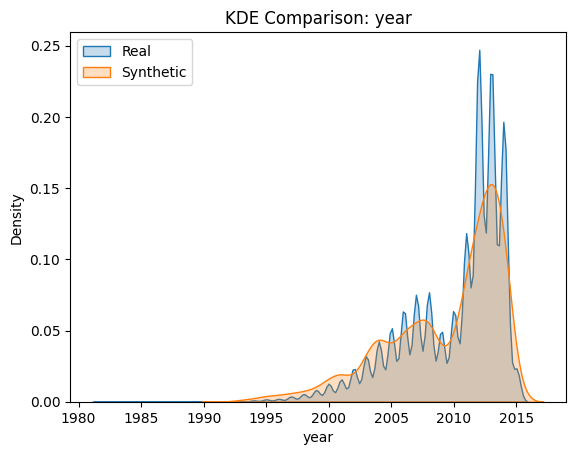

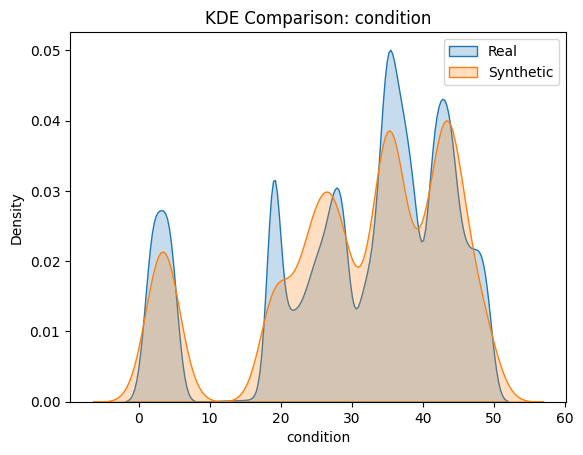

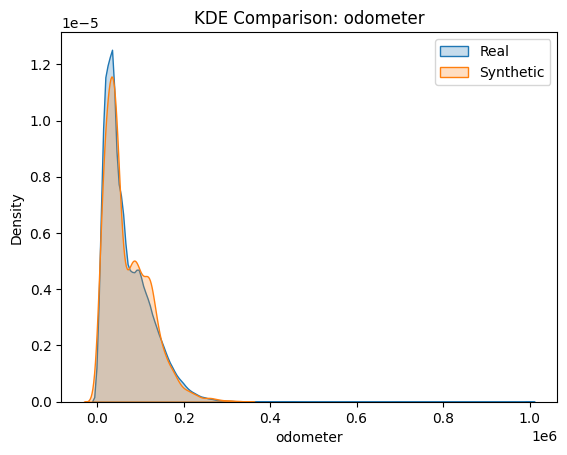

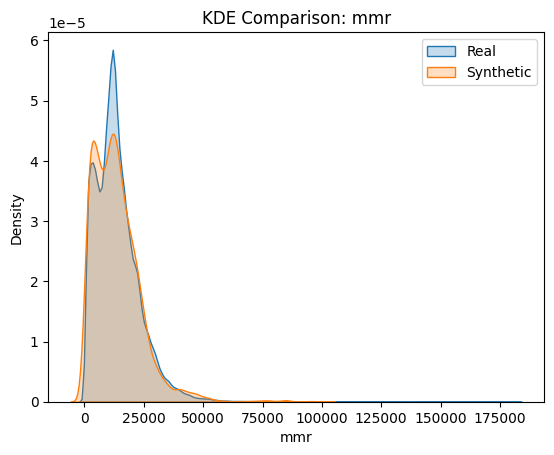

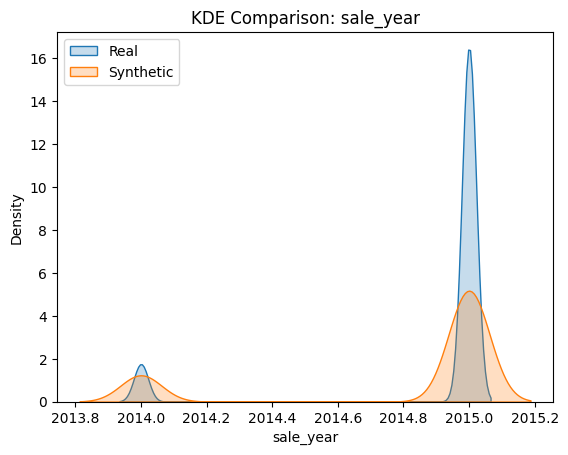

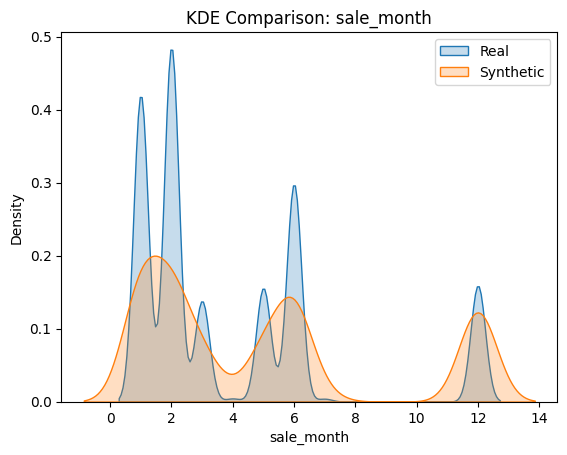

Running KS test...
       column   ks_stat        p_value
0        year  0.072746   1.858430e-45
1   condition  0.071583   4.994728e-44
2    odometer  0.028575   2.263314e-07
3         mmr  0.053062   2.242510e-24
4   sale_year  0.095804   1.373704e-78
5  sale_month  0.120586  2.140273e-124
Categorical comparison...


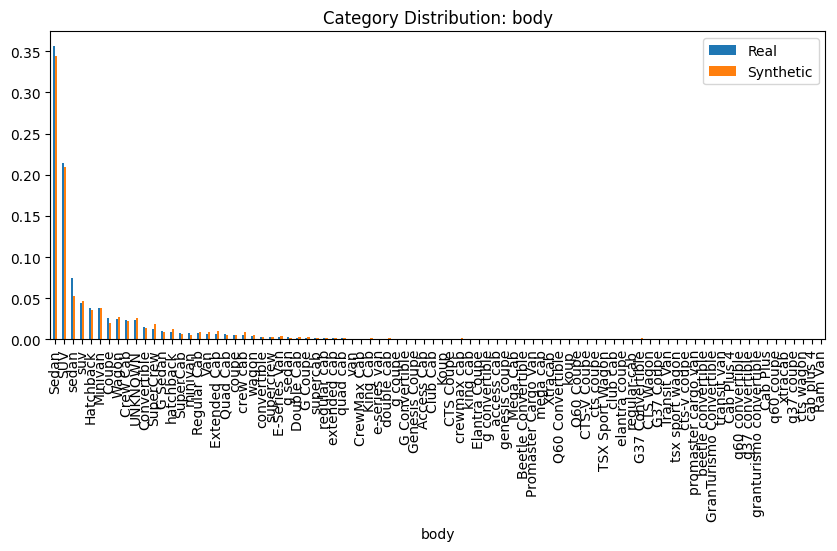

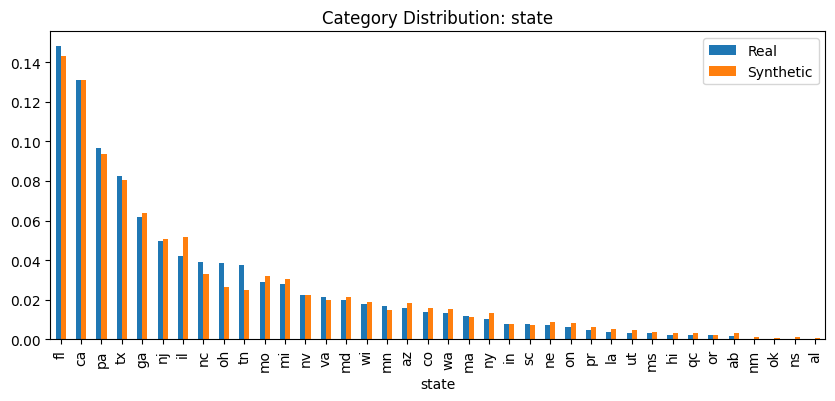

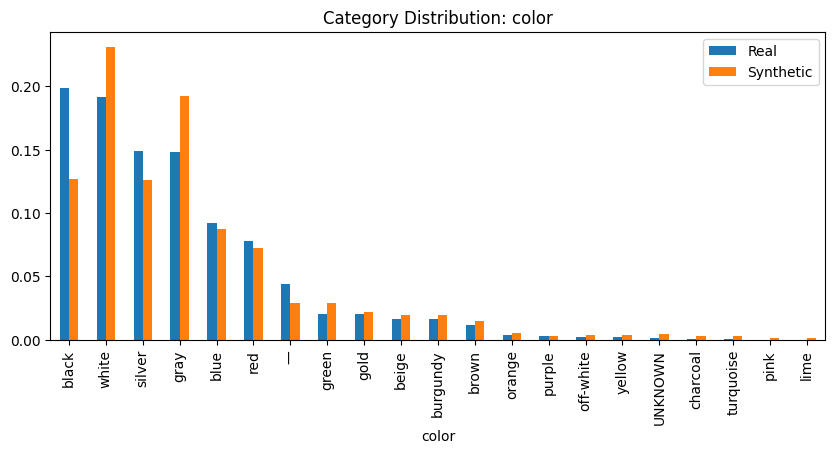

Correlation comparison...


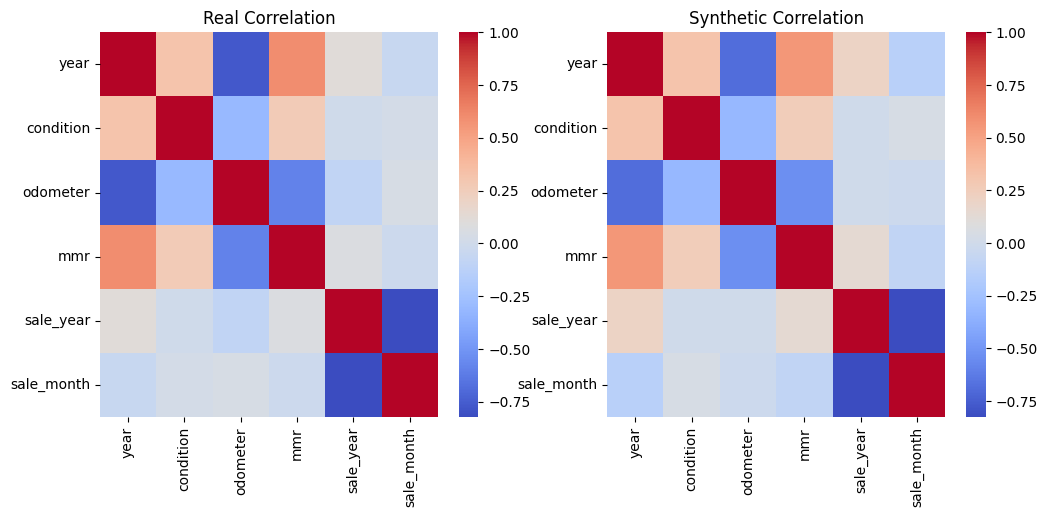

ML utility test...
ML Utility (R²): 0.8551
ML Utility (RMSE): 13769366.3897


In [ ]:
# INPUTS
real_df = vs_df.copy()
syn_df = synthetic_df.copy()

target = "sellingprice"

numeric_cols = [
    "year", "condition", "odometer", "mmr", "sale_year", "sale_month"
]

categorical_cols = [
    "body", "state", "color"
]

# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    # One-hot encode
    real_enc = pd.get_dummies(real)
    syn_enc = pd.get_dummies(syn)

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)

    X_real = real_enc.drop(columns=[target])
    y_real = real_enc[target]

    X_syn = syn_enc.drop(columns=[target])
    y_syn = syn_enc[target]

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    score = r2_score(y_real, preds)
    print(f"ML Utility (R²): {score:.4f}")

    rmse = mean_squared_error(y_real, preds)
    print(f"ML Utility (RMSE): {rmse:.4f}")

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)

# 10k Samples

```
Running KS test...
       column   ks_stat        p_value
0        year  0.072746   1.858430e-45
1   condition  0.071583   4.994728e-44
2    odometer  0.028575   2.263314e-07
3         mmr  0.053062   2.242510e-24
4   sale_year  0.095804   1.373704e-78
5  sale_month  0.120586  2.140273e-124
Categorical comparison...

```

```
ML utility test...
ML Utility (R²): 0.8551
ML Utility (RMSE): 13769366.3897
```

#Repeat for TVAE

In [ ]:
from ctgan import TVAE

tvae = TVAE(cuda=True)

/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [ ]:
#Can be loaded to skip future preprocessing
vs_df = pd.read_csv(base_path+"/vehicle_sales_preprocessed.csv")

In [ ]:
tvae = TVAE(cuda=True)

start_time = time.time()
print(f"Fitting TVAE Model [{start_time}]...")
tvae.fit(
    vs_df,
    discrete_columns = [
  "model",
  "body",
  "state",
  "color",
  "year_missing",
  "condition_missing",
  "odometer_missing",
  "mmr_missing",
  "sellingprice_missing",
  "sale_year",
  "sale_month",
  "sale_day",
  "sale_hour"
])
end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {end_time- start_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = tvae.sample(1000)
end_time = time.time()
samples.to_csv(base_path+"/tvae_vehicle_samples.csv", index=False)


print(f"1000 Samples in {start_time - end_time}.")

start_time = time.time()
print(f"Starting large batch of samples [{start_time}].")

for i in range(10):
  samples = tvae.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/tvae_vehicle_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/tvae_vehicle_samples_large.csv", mode="a", header=False, index=False)

end_time = time.time()
print(f"1000 Samples in {end_time - start_time}. Finished [{end_time}].")

/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [ ]:
synthetic_df = pd.read_csv(base_path+"/tvae_vehicle_samples_large.csv")

Running KDE plots...


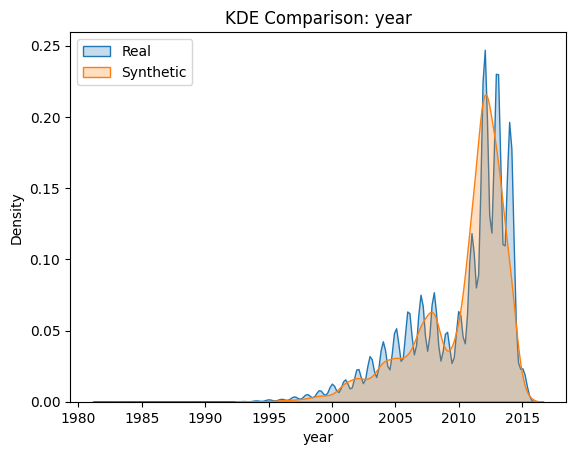

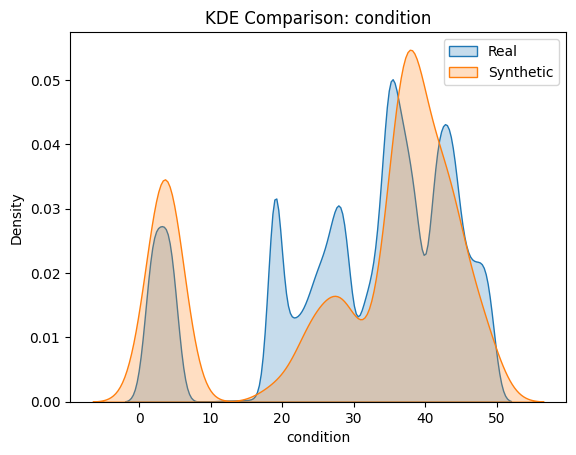

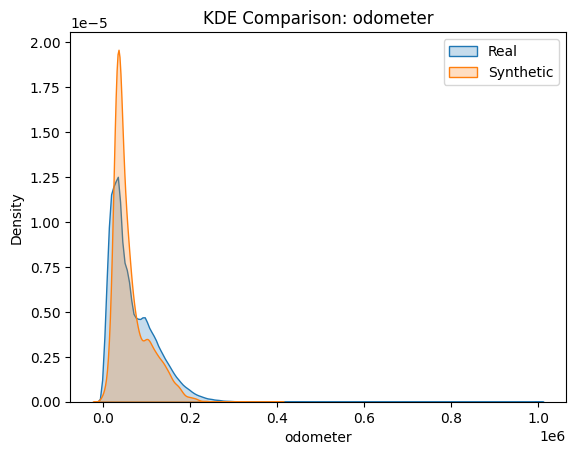

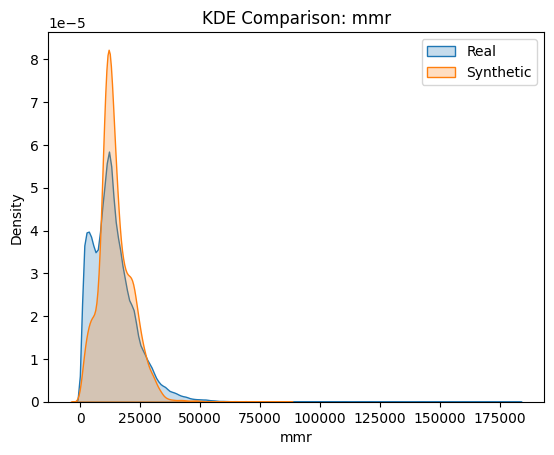

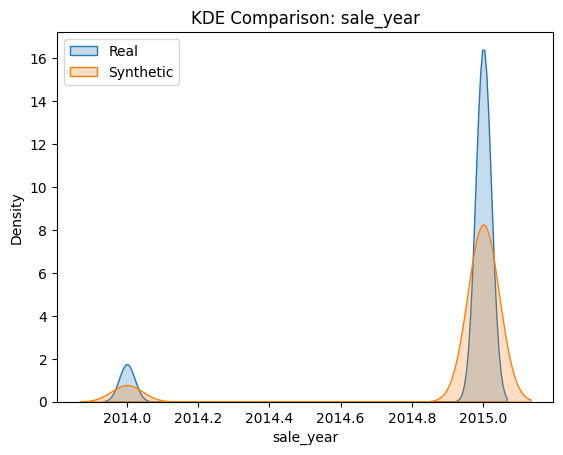

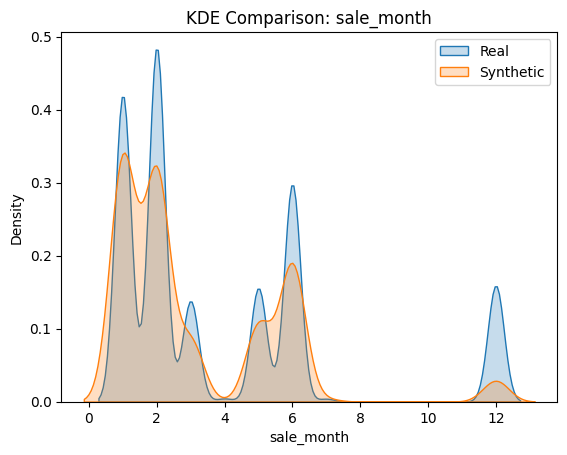

Running KS test...
       column   ks_stat        p_value
0        year  0.058829   7.244054e-30
1   condition  0.146767  2.373138e-184
2    odometer  0.134616  4.842384e-155
3         mmr  0.151354  4.346947e-196
4   sale_year  0.010996   1.863489e-01
5  sale_month  0.069597   1.220427e-41
Categorical comparison...


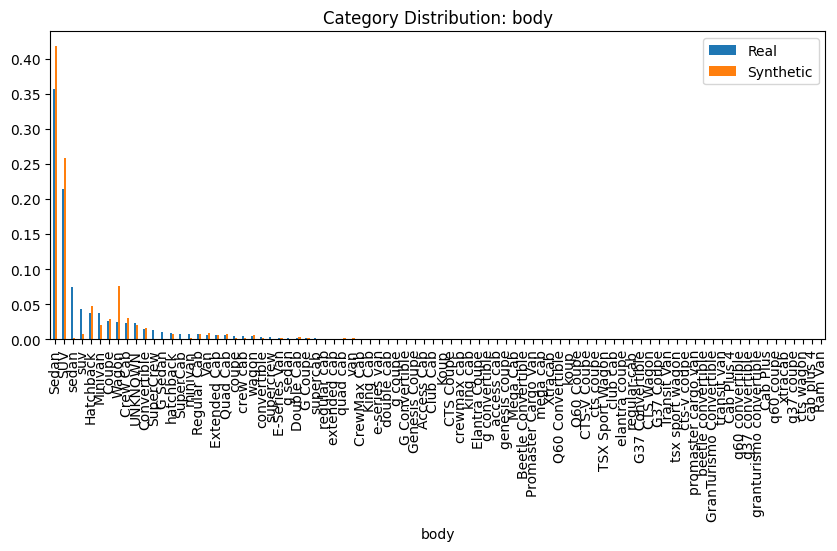

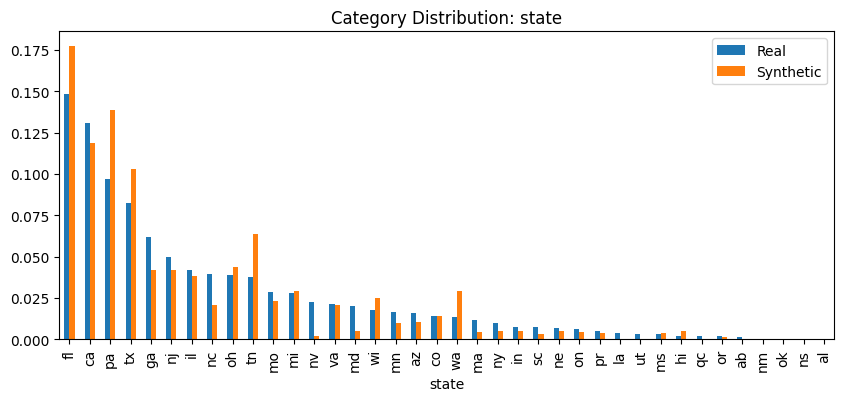

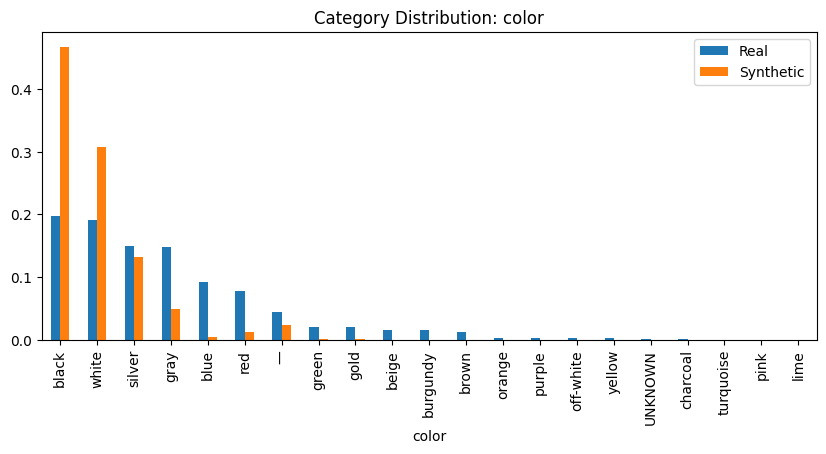

Correlation comparison...


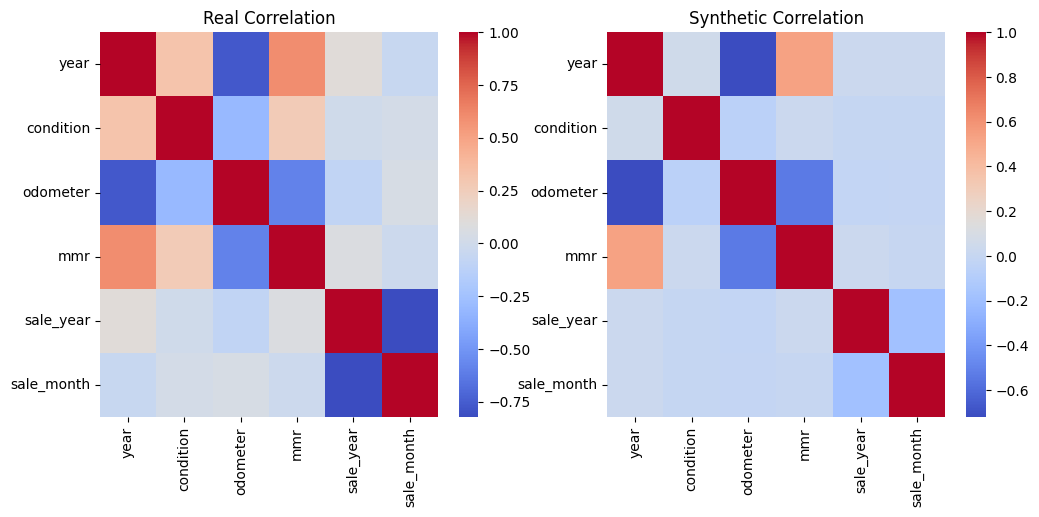

In [ ]:
# INPUTS
real_df = vs_df.copy()
syn_df = synthetic_df.copy()

target = "sellingprice"

numeric_cols = [
    "year", "condition", "odometer", "mmr", "sale_year", "sale_month"
]

categorical_cols = [
    "body", "state", "color"
]

# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    # One-hot encode
    real_enc = pd.get_dummies(real)
    syn_enc = pd.get_dummies(syn)

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)

    X_real = real_enc.drop(columns=[target])
    y_real = real_enc[target]

    X_syn = syn_enc.drop(columns=[target])
    y_syn = syn_enc[target]

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    score = r2_score(y_real, preds)
    print(f"ML Utility (R²): {score:.4f}")

    rmse = mean_squared_error(y_real, preds)
    print(f"ML Utility (RMSE): {rmse:.4f}")

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)

#TVAE 1,000 Samples

```
Running KS test...
       column   ks_stat       p_value
0        year  0.069221  1.330085e-04
1   condition  0.148267  1.293784e-19
2    odometer  0.139976  1.602756e-17
3         mmr  0.158154  2.852447e-22
4   sale_year  0.025896  5.067543e-01
5  sale_month  0.073536  3.869259e-05
Categorical comparison...
```


```
ML utility test...
ML Utility (R²): 0.8801
ML Utility (RMSE): 11386983.0276
```



#TVAE 10,000 Samples



```
Running KS test...
       column   ks_stat        p_value
0        year  0.058829   7.244054e-30
1   condition  0.146767  2.373138e-184
2    odometer  0.134616  4.842384e-155
3         mmr  0.151354  4.346947e-196
4   sale_year  0.010996   1.863489e-01
5  sale_month  0.069597   1.220427e-41
Categorical comparison...
```


```
ML utility test...
ML Utility (R²): 0.9164
ML Utility (RMSE): 7947299.6915
```




#Repeat for Diffusion Models
--Failed to get this working in time--




In [ ]:
import os
import sys

In [ ]:
REPO_DIR = "/content/drive/MyDrive/tab-ddpm"

%env REPO_DIR={REPO_DIR}
%env PROJECT_DIR={REPO_DIR}

if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

if not os.path.exists(REPO_DIR):
  !git clone https://github.com/yandex-research/tab-ddpm "{REPO_DIR}"

%cd "{REPO_DIR}"

# Outdated, but likely compatible with newer versions. (From the tab-ddpm github readme)
# !pip install torch==1.10.1+cu111 -f https://pytorch.org
# !pip install -r requirements.txt

import torch
print(f"Using PyTorch {torch.__version__} with CUDA {torch.version.cuda}")

!pip install catboost
!pip install -r requirements.txt

env: REPO_DIR=/content/drive/MyDrive/tab-ddpm
env: PROJECT_DIR=/content/drive/MyDrive/tab-ddpm
/content/drive/MyDrive/tab-ddpm
Using PyTorch 2.10.0+cu128 with CUDA 12.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement catboost==1.0.3 (from versions: 1.2, 1.2.1, 1.2.2, 1.2.3, 1.2.5, 1.2.6, 1.2.7, 1.2.8, 1.2.9, 1.2.10)
ERROR: No matching distribution found for catboost==1.0.3


In [ ]:
vs_df = preprocess(vs_df)

NameError: name 'preprocess' is not defined

# Advanced Preprocessing
The other two models automate this step. This model is newer, and a seamless API was not available. Therefore, we must do the preprocessing manually.

Steps:



*   Reduce Cardinality of High Cardinality Categoricals
*   Encode Categoricals
*   Scale Transform Numericals

Then we must create an inverse of the transform as well as clipping and rounding values. The model is unable to enforce boundaries, such as maximum values.



In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder


class TabularDiffusionPreprocessingPipeline:
    def __init__(self, categorical_cols, numerical_cols, max_categories=50):
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        self.max_categories = max_categories

        self.scaler = StandardScaler()
        self.encoders = {}
        self.top_categories = {}


    #Preprocessing
    def fit(self, df):
        df = df.copy()

        # Reduce high-cardinality columns
        for col in self.categorical_cols:
            if df[col].nunique() > self.max_categories:
                top_vals = df[col].value_counts().nlargest(self.max_categories).index
                df[col] = df[col].where(df[col].isin(top_vals), "other")
                self.top_categories[col] = set(top_vals)

        # Fit label encoders
        for col in self.categorical_cols:
            le = LabelEncoder()
            df[col] = df[col].astype(str)
            le.fit(df[col])
            self.encoders[col] = le

        # Fit scaler
        self.scaler.fit(df[self.numerical_cols])

        return self

    #Transform (to tensor)
    def transform(self, df):
        df = df.copy()

        # Apply category reduction
        for col in self.categorical_cols:
            if col in self.top_categories:
                df[col] = df[col].where(
                    df[col].isin(self.top_categories[col]), "other"
                )

        # Encode categorical
        cat_arrays = []
        for col in self.categorical_cols:
            le = self.encoders[col]
            df[col] = df[col].astype(str)
            cat_arrays.append(le.transform(df[col]))

        cat_encoded = np.column_stack(cat_arrays)

        # Scale numerical
        num_scaled = self.scaler.transform(df[self.numerical_cols])

        # Combine
        X = np.concatenate([num_scaled, cat_encoded], axis=1)

        return torch.tensor(X, dtype=torch.float32)


    #Inverse Transform
    def inverse_transform(self, tensor):
        X = tensor.detach().cpu().numpy()

        num_dim = len(self.numerical_cols)

        num_part = X[:, :num_dim]
        cat_part = X[:, num_dim:]

        # Inverse scale numerical
        num_original = self.scaler.inverse_transform(num_part)

        # Decode categorical
        cat_decoded = {}
        for i, col in enumerate(self.categorical_cols):
            le = self.encoders[col]

            # Clamp + round
            vals = np.round(cat_part[:, i]).astype(int)
            vals = np.clip(vals, 0, len(le.classes_) - 1)

            cat_decoded[col] = le.inverse_transform(vals)

        df_num = pd.DataFrame(num_original, columns=self.numerical_cols)
        df_cat = pd.DataFrame(cat_decoded)

        return pd.concat([df_num, df_cat], axis=1)

    #DataLoader
    def get_dataloader(self, tensor, batch_size=512):
        dataset = TensorDataset(tensor)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
categorical_cols = [
  "model",
  "body",
  "state",
  "color",
  "condition_missing",
  "odometer_missing",
  "sale_year",
  "sale_month",
  "sale_day",
  "sale_hour"
]

numerical_cols = [
  "year",
  "condition",
  "odometer",
  "mmr",
  "sellingprice"
]

In [ ]:
pipeline = TabularDiffusionPreprocessingPipeline(
    categorical_cols,
    numerical_cols,
    max_categories=50
)

pipeline.fit(vs_df)

KeyError: 'condition_missing'

In [ ]:
X = pipeline.transform(vs_df)

In [ ]:
loader = pipeline.get_dataloader(X, batch_size=512)

In [ ]:
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/tab-ddpm']


In [ ]:
from tab_ddpm.gaussian_multinomial_diffsuion import *
from tab_ddpm.modules import *
from tab_ddpm.utils import *
#from tab_ddpm.scripts import utils_train


#Need to define the model that will remove noise from the data
We will use a multilayer perceptron

In [ ]:
import torch.nn as nn

class DenoiseMLP(nn.Module):
  def __init__(self, input_dim, hidden_dim=512):
    super().__init__()

    self.time_embed = nn.Embedding(1000, hidden_dim)

    self.net = nn.Sequential(
        nn.Linear(hidden_dim + input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, input_dim)
    )

  def forward(self, x, t):
    t_embed = self.time_embed(t)

    x = torch.cat([x, t_embed], dim=1)

    return self.net(x)

In [ ]:
input_dim = X.shape[1]
model = DenoiseMLP(input_dim)


In [ ]:
# K = [
#     len(pipeline.encoders[col].classes_)
#     for col in categorical_cols
# ]

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


K = torch.tensor(
    [len(pipeline.encoders[col].classes_) for col in categorical_cols]
)

# print(K)

From the GitHub (model signature):


```
class GaussianMultinomialDiffusion(torch.nn.Module):
    def __init__(
            self,
            num_classes: np.array,
            num_numerical_features: int,
            denoise_fn,
            num_timesteps=1000,
            gaussian_loss_type='mse',
            gaussian_parametrization='eps',
            multinomial_loss_type='vb_stochastic',
            parametrization='x0',
            scheduler='cosine',
            device=torch.device('cpu')
        ):
```
alternatively: device = torch.device('cuda:1'),


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

diffusion = GaussianMultinomialDiffusion(
    num_classes = K,
    num_numerical_features = len(numerical_cols),
    denoise_fn=model,
    num_timesteps=1000,
    gaussian_loss_type='rmse',
    device = device,
    )

In [ ]:
!pip install zero

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.1/258.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: Click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fiona 1.10.1 requires click~=8.0, but you have click 7.0 which is incompatible.
wandb 0.25.1 requires click>=8.0.1, but you have click 7.0 which is incompatible.
typer 0.24.1 requires click>=8.2.1, but you have click 7.0 which is incompatible.
pyiceberg 0.11.1 requires click<9.0.0,>

In [ ]:
import torch
import torch.nn as nn

class MyDenoiseWrapper:
    def __init__(self, input_dim, device):
        self.model = DenoiseMLP(input_dim).to(device)
        self.device = device
        self.optim = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.criterion = nn.MSELoss()

    def fit(self, X, y, epochs=20, batch_size=256):
        self.model.train()

        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device)

        dataset = torch.utils.data.TensorDataset(X, y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

        for _ in range(epochs):
            for xb, yb in loader:
                pred = self.model(xb)
                loss = self.criterion(pred, yb)

                self.optim.zero_grad()
                loss.backward()
                self.optim.step()

    def predict(self, X):
        self.model.eval()

        X = torch.tensor(X, dtype=torch.float32, device=self.device)

        with torch.no_grad():
            preds = self.model(X)

        return preds.cpu().numpy()

In [ ]:
!ls

#!pip install scripts

drive  sample_data


In [ ]:
# python scripts/pipeline.py \
#   --config exp/churn2/ddpm_cb_best/config.toml \
#   --train --sample

!python scripts/eval_seeds.py \
  --config exp/churn2/ddpm_cb_best/config.toml \
  10 ddpm synthetic mlp 5

python3: can't open file '/content/scripts/eval_seeds.py': [Errno 2] No such file or directory


In [ ]:
import tab_ddpm
print(dir(tab_ddpm))

['Any', 'Callable', 'Dict', 'F', 'FoundNANsError', 'GEGLU', 'GaussianMultinomialDiffusion', 'List', 'MLP', 'MLPDiffusion', 'ModuleType', 'Optional', 'ReGLU', 'ResNet', 'ResNetDiffusion', 'SiLU', 'Tensor', 'Tuple', 'Type', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'approx_standard_normal_cdf', 'betas_for_alpha_bar', 'cast', 'default', 'discretized_gaussian_log_likelihood', 'eps', 'exists', 'extract', 'gaussian_multinomial_diffsuion', 'geglu', 'get_named_beta_schedule', 'index_to_log_onehot', 'isfunction', 'log_1_min_a', 'log_add_exp', 'log_categorical', 'log_onehot_to_index', 'log_sub_exp', 'log_sum_exp_by_classes', 'math', 'mean_flat', 'modules', 'nn', 'normal_kl', 'np', 'ohe_to_categories', 'record_function', 'reglu', 'sliced_logsumexp', 'sum_except_batch', 'timestep_embedding', 'torch', 'utils']


In [ ]:
!python scripts/train.py \
  --config configs/adult.yaml \
  --train_path data/adult/train.csv

ImportError: cannot import name 'Trainer' from 'tab_ddpm' (/content/drive/MyDrive/tab-ddpm/tab_ddpm/__init__.py)

#Gaussian Copula Synthesizer


In [ ]:
!pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 135.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00


In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

data = vs_df.copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

gcs = GaussianCopulaSynthesizer(metadata)
gcs.fit(data)

samples = gcs.sample(1000)

samples.to_csv(base_path+"/gsc_vehicle_samples.csv", index=False)

for i in range(10):
  samples = gcs.sample(1000)
  if i == 0:
    samples.to_csv(base_path+"/gcs_vehicle_samples_large.csv", index=False)
  else:
    samples.to_csv(base_path+"/gcs_vehicle_samples_large.csv", mode="a", header=False, index=False)

ModuleNotFoundError: No module named 'sdv'

In [17]:
synthetic_df = pd.read_csv(base_path+"/gcs_vehicle_samples_large.csv")

In [23]:
# INPUTS
real_df = vs_df.copy()
syn_df = synthetic_df.copy()

target = "sellingprice"

numeric_cols = [
    "year", "condition", "odometer", "mmr", "sale_year", "sale_month"
]

categorical_cols = [
    "body", "state", "color"
]

# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    # One-hot encode
    real_enc = pd.get_dummies(real)
    syn_enc = pd.get_dummies(syn)

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)

    X_real = real_enc.drop(columns=[target])
    y_real = real_enc[target]

    X_syn = syn_enc.drop(columns=[target])
    y_syn = syn_enc[target]

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    score = r2_score(y_real, preds)
    print(f"ML Utility (R²): {score:.4f}")

    rmse = mean_squared_error(y_real, preds)
    print(f"ML Utility (RMSE): {rmse:.4f}")

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target)

ML utility test...
ML Utility (R²): 0.9502
ML Utility (RMSE): 4735542.4098


#GCS 10k Samples


```
Running KS test...
       column   ks_stat       p_value
0        year  0.107798  1.959924e-99
1   condition  0.107344  1.339496e-98
2    odometer  0.040034  4.663716e-14
3         mmr  0.051946  2.229436e-23
4   sale_year  0.001196  1.000000e+00
5  sale_month  0.008403  4.919301e-01
Categorical comparison...
```



```
ML utility test...
ML Utility (R²): 0.9502
ML Utility (RMSE): 4735542.4098
```



#Also look into SMOTE

In [ ]:
#%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
#from sdv.single_table import GaussianCopulaSynthesizer
# import torch
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.preprocessing import StandardScaler, LabelEncoder